# 03 · Feature-selection comparison

Comparison of the best recorded XGBoost FFS configuration for each ranking operator with the all-variable and Boruta reference baselines and the final RFFS set. No additional ranking experiment is performed in this notebook.


### Setup

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from _shared import ONE_HALF_COL, OPERATORS, OPERATOR_LABELS, SINGLE_COL, init_notebook, jload, run_dir

FIG_DIR, savefig = init_notebook("03_baselines")

campaign: dce-full-rffs-4backbones-xgb-analyses-v2-2026-08-11
figures -> /Users/berthier/Development/PhD/xopa/results/notebook-figures/03_baselines


In [2]:
base_dir = run_dir("xgboost", "baselines")
rffs_dir = run_dir("xgboost", "rffs")
comparison_dir = run_dir("xgboost", "comparison")

decision = jload(base_dir / "boruta_decision.json")
history = pd.read_csv(base_dir / "boruta_decision_history.csv")
recorded_sets = jload(base_dir / "selected_sets.json")
rffs = jload(rffs_dir / "rffs_summary.json")
model_comparison = pd.read_csv(comparison_dir / "model_comparison.csv")

In [3]:
def recorded_xgboost_row(feature_set: str, split: str = "val") -> pd.Series:
    rows = model_comparison.loc[
        (model_comparison["feature_set"] == feature_set)
        & (model_comparison["backbone"] == "xgboost")
        & (model_comparison["split"] == split)
    ]
    if len(rows) != 1:
        raise ValueError(
            f"expected one recorded XGBoost {split} row for {feature_set}, found {len(rows)}"
        )
    return rows.iloc[0]


def jaccard_frame(feature_sets: dict[str, list[str]]) -> pd.DataFrame:
    labels = list(feature_sets)
    matrix = pd.DataFrame(1.0, index=labels, columns=labels)
    for index, left in enumerate(labels):
        left_set = set(feature_sets[left])
        for right in labels[index + 1 :]:
            right_set = set(feature_sets[right])
            union = left_set | right_set
            value = len(left_set & right_set) / len(union) if union else 1.0
            matrix.loc[left, right] = matrix.loc[right, left] = value
    return matrix

In [4]:
comparison_rows = []
best_sets = {
    "Boruta": list(recorded_sets["boruta_confirmed"]),
    "RFFS": list(rffs["final_features"]),
}

for operator in OPERATORS:
    grid = pd.read_csv(rffs_dir / f"grid_eval_{operator}.csv")
    best = grid.sort_values(["val_mse", "K"], ascending=[True, True]).iloc[0]
    K = int(best["K"])
    features = jload(rffs_dir / f"survivors_{operator}.json")[str(K)]
    if len(features) != int(best["d_star"]):
        raise ValueError(f"{operator} survivor count does not match its recorded grid row")
    label = f"FFS ({OPERATOR_LABELS[operator]})"
    best_sets[label] = features
    comparison_rows.append(
        {
            "method": label,
            "role": "preliminary FFS configuration",
            "setting": f"K={K}",
            "n_features": len(features),
            "validation_mse": float(best["val_mse"]),
            "validation_r2": float(best["val_r2"]),
        }
    )

In [5]:
all_row = recorded_xgboost_row("all_features")
boruta_row = recorded_xgboost_row("boruta_confirmed")
rffs_row = recorded_xgboost_row("rffs_summary_d_plus")
comparison_rows.extend(
    [
        {
            "method": "All variables",
            "role": "reference baseline",
            "setting": "no selection",
            "n_features": int(all_row["n_features"]),
            "validation_mse": float(all_row["mse"]),
            "validation_r2": float(all_row["r2"]),
        },
        {
            "method": "Boruta",
            "role": "reference baseline",
            "setting": "self-sized",
            "n_features": int(boruta_row["n_features"]),
            "validation_mse": float(boruta_row["mse"]),
            "validation_r2": float(boruta_row["r2"]),
        },
        {
            "method": "RFFS",
            "role": "final proposed set",
            "setting": f"d+={int(rffs['d_plus'])}",
            "n_features": int(rffs_row["n_features"]),
            "validation_mse": float(rffs_row["mse"]),
            "validation_r2": float(rffs_row["r2"]),
        },
    ]
)

In [6]:
comparison = pd.DataFrame(comparison_rows)
expected_methods = {
    "All variables",
    "Boruta",
    "FFS (RFE)",
    "FFS (mRMR)",
    "FFS (LASSO)",
    "FFS (Model importance)",
    "RFFS",
}
if set(comparison["method"]) != expected_methods:
    raise ValueError("recorded FFS comparison is incomplete")
if not np.isfinite(comparison[["validation_mse", "validation_r2"]].to_numpy()).all():
    raise ValueError("recorded validation metrics must be finite")
if (comparison["validation_mse"] < 0).any():
    raise ValueError("recorded validation MSE values must be non-negative")

overlap = jaccard_frame(best_sets)
comparison.to_csv(FIG_DIR / "best_ffs_comparison.csv", index=False)
(FIG_DIR / "best_ffs_sets.json").write_text(json.dumps(best_sets, indent=2))

print(
    f"Boruta: {len(decision['confirmed'])} confirmed, {len(decision['tentative'])} "
    f"tentative, {len(decision['rejected'])} rejected in {decision['n_iter']} iterations"
)
comparison.sort_values(["role", "method"])[
    ["method", "role", "setting", "n_features", "validation_mse", "validation_r2"]
].round(4)

Boruta: 67 confirmed, 2 tentative, 247 rejected in 100 iterations


,method,role,setting,n_features,validation_mse,validation_r2
6,RFFS,final proposed set,d+=20,20,0.2030,0.7951
2,FFS (LASSO),preliminary FFS configuration,K=130,107,0.2294,0.7685
3,FFS (Model importance),preliminary FFS configuration,K=170,154,0.2189,0.7791
0,FFS (RFE),preliminary FFS configuration,K=110,97,0.2161,0.7819
1,FFS (mRMR),preliminary FFS configuration,K=150,146,0.2630,0.7346
4,All variables,reference baseline,no selection,316,0.2185,0.7795
5,Boruta,reference baseline,self-sized,67,0.3195,0.6775


## Boruta decision trajectory

Cumulative confirmed and rejected features over the 100 iterations.

saved: /Users/berthier/Development/PhD/xopa/results/notebook-figures/03_baselines/boruta_trajectory.pdf/.png


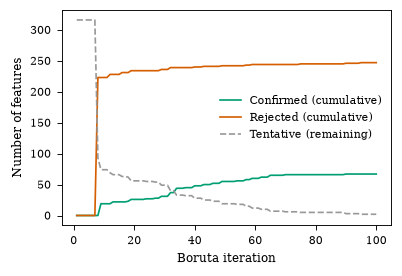

In [7]:
per_iter = history.groupby("iteration")[
    ["accepted_this_iteration", "rejected_this_iteration"]
].sum()
cum = per_iter.cumsum()
undecided = len(recorded_sets["boruta_confirmed"]) + len(decision["tentative"]) + len(
    decision["rejected"]
) - cum.sum(axis=1)

fig, ax = plt.subplots(figsize=(SINGLE_COL, 2.4))
ax.plot(cum.index, cum["accepted_this_iteration"], color="#009E73", label="Confirmed (cumulative)")
ax.plot(cum.index, cum["rejected_this_iteration"], color="#D55E00", label="Rejected (cumulative)")
ax.plot(undecided.index, undecided, color="#999999", ls="--", label="Tentative (remaining)")
ax.set_xlabel("Boruta iteration")
ax.set_ylabel("Number of features")
ax.legend()
savefig(fig, "boruta_trajectory")
plt.show()

## Best recorded configurations and reference baselines

Each ranking operator is represented by its validation-selected FFS configuration from the grid reported in Figure 5 of the manuscript.  
The all-variable model and Boruta are reference baselines, while RFFS is shown at its final validation-selected dimension. The notebook does not introduce a separate one-shot selection protocol.


saved: /Users/berthier/Development/PhD/xopa/results/notebook-figures/03_baselines/selection_frontier.pdf/.png


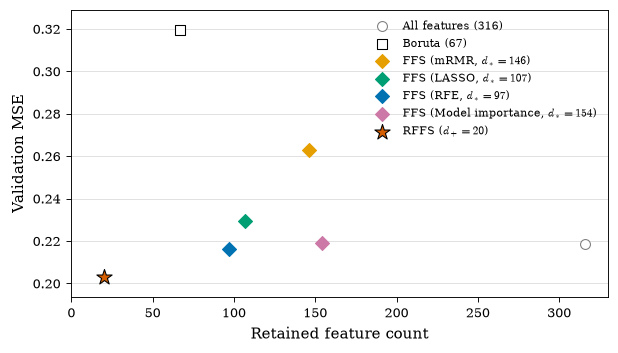

In [8]:
method_order = [
    "All variables",
    "Boruta",
    "FFS (mRMR)",
    "FFS (LASSO)",
    "FFS (RFE)",
    "FFS (Model importance)",
    "RFFS",
]
method_styles = {
    "All variables": ("#7F7F7F", "o", False),
    "Boruta": ("#000000", "s", False),
    "FFS (mRMR)": ("#E69F00", "D", True),
    "FFS (LASSO)": ("#009E73", "D", True),
    "FFS (RFE)": ("#0072B2", "D", True),
    "FFS (Model importance)": ("#CC79A7", "D", True),
    "RFFS": ("#D55E00", "*", True),
}
comparison_indexed = comparison.set_index("method").loc[method_order]
def legend_label(method: str, n: int) -> str:
    """Legend entry with the recorded set size (never typed by hand)."""
    if method == "All variables":
        return f"All features ({n})"
    if method == "Boruta":
        return f"Boruta ({n})"
    if method == "RFFS":
        return rf"RFFS ($d_+={n}$)"
    operator = method[len("FFS ("):-1]
    return rf"FFS ({operator}, $d_*={n}$)"

fig, ax = plt.subplots(figsize=(ONE_HALF_COL, 3.1))
handles = []
for method, row in comparison_indexed.iterrows():
    color, marker, filled = method_styles[method]
    point = ax.scatter(
        row["n_features"],
        row["validation_mse"],
        s=110 if method == "RFFS" else 42,
        marker=marker,
        facecolor=color if filled else "white",
        edgecolor="black" if method == "RFFS" else color,
        linewidth=0.7,
        zorder=4 if method == "RFFS" else 3,
        label=legend_label(method, int(row["n_features"])),
    )
    handles.append(point)

ax.set_xlabel("Retained feature count", fontsize=9.5)
ax.set_ylabel("Validation MSE", fontsize=9.5)
ax.tick_params(labelsize=8.5)
ax.set_xlim(0, 330)
mse_min, mse_max = comparison["validation_mse"].agg(["min", "max"])
mse_span = max(float(mse_max - mse_min), 1e-3)
ax.set_ylim(float(mse_min) - 0.08 * mse_span, float(mse_max) + 0.08 * mse_span)
ax.grid(axis="y", color="#D9D9D9", linewidth=0.5, zorder=0)
ax.legend(handles=handles, ncol=1, fontsize=7.5, loc="upper right")
savefig(fig, "selection_frontier")
plt.show()
